In [ ]:
using Pkg; Pkg.add(["ITensors", "ITensorMPS", "Plots", "LsqFit", "Statistics", "LinearAlgebra", "ProgressMeter", "LaTeXStrings", "SavitzkyGolay"])
using ITensors, ITensorMPS, Plots, LsqFit, Statistics, LinearAlgebra, ProgressMeter, LaTeXStrings, SavitzkyGolay

include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")



   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`
   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`


Dict{String, Any} with 6 entries:
  "Δ"            => -1.0
  "J"            => -1.0
  "μ"            => 1.0
  "MAX_BOND_DIM" => 1000
  "NUM_SWEEPS"   => 25
  "ACC"          => 1.0e-16

In [2]:
function fetch_states(
    N::Int, σ::Float64, system_params::Dict{String, Any};
    max::Union{Nothing, Int}=nothing, type::Symbol=:latest
)::Tuple{Vector{MPS}, Vector{MPS}}
    CURRENT_DIR = @__DIR__
    FP = extract_filename_from_system_params(system_params)
    MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(σ)_$(FP).hd5")
    matches_cln = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=type)
    matches_dis = find_runs_by_params(MPS_FP, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=type)

    cln_mpss = MPS[]
    dis_mpss = MPS[]

    for (cln, dis) in zip(matches_cln, matches_dis)
        if (cln.psi === nothing || dis.psi === nothing)
            continue
        end

        push!(cln_mpss, cln.psi)
        push!(dis_mpss, dis.psi)

        if max !== nothing && length(cln_mpss) >= max
            break
        end
    end

    return cln_mpss, dis_mpss
end

fetch_states (generic function with 1 method)

In [4]:
function get_squared_sorted_schmidt_spectrum_from_mps(psi::MPS)
    N = length(psi)

    # MIDDLE bond
    middle_bond = N ÷ 2

    orthogonalize!(psi, middle_bond)
    link_idx = linkind(psi, middle_bond)
    _, S, _ = svd(psi[middle_bond], (siteind(psi, middle_bond), link_idx))

    schmidt_dim = dim(S, 1)

    schmidt_vals = []
    for n in 1:schmidt_dim
        push!(schmidt_vals, S[n, n]) # steal diagonals
    end

    # sort desc and square
    return sort(schmidt_vals .^ 2, rev=true)
end

get_squared_sorted_schmidt_spectrum_from_mps (generic function with 1 method)

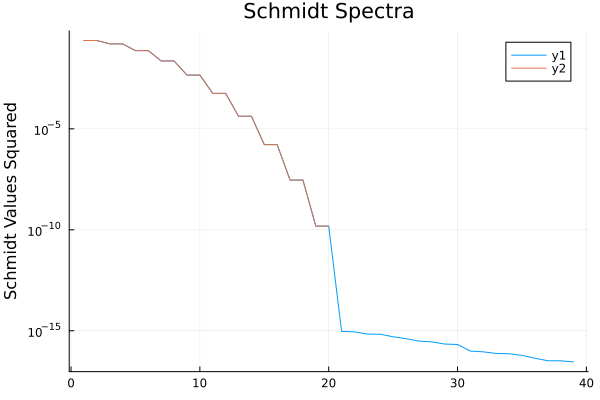

In [ ]:
sysparams = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 25, "MAX_BOND_DIM" => 2000, "ACC" => 10^-16
)

N = 40
σ = 1e-6

p = plot(title="Schmidt Spectra", ylabel="Schmidt Values Squared", legend=:topright,
    yscale=:log,
    # xscale=:log
)

cln, dis = fetch_states(N, σ, sysparams; type=:latest)
spectra = get_squared_sorted_schmidt_spectrum_from_mps(dis[1])
spectra_cln = get_squared_sorted_schmidt_spectrum_from_mps(cln[1])

plot!(p, 1:length(spectra), spectra)
plot!(p, 1:length(spectra_cln), spectra_cln)

display(p)